# Lecture 04 · Teach a Robot with PPO 🤖  — PPO from scratch (continuous control)

**RL in Production · Vizuara AI Labs**

In Lecture 3 you climbed the variance ladder — REINFORCE → +baseline → Actor-Critic —
on the discrete Archer. Lecture 4 takes the next step: the robot's actuators are
**continuous** (a torque, a thruster), and we want updates that are **big enough to
learn fast** but **small enough not to fall off a cliff**. That tension is the whole
story of TRPO → **PPO**.

You will implement **Proximal Policy Optimization from scratch in PyTorch** (no
Stable-Baselines3) and teach a robot two continuous-control tasks:

> **Pendulum-v1** (swing a torque-limited arm upright) → **LunarLanderContinuous-v3** (land a lander with two analog thrusters)

The two ideas that make PPO work are exactly the two you will build:

1. **The clipped surrogate** — let the policy ratio $r=\pi/\pi_{\text{old}}$ move,
   but **clip** it to $[1-\varepsilon,\,1+\varepsilon]$ so one batch can't shove the
   policy too far. This is the trust-region idea from TRPO, made cheap.
2. **Sample reuse** — because clipping keeps each step honest, we can safely take
   **K gradient epochs** over the *same* batch instead of throwing it away.

You will also run the lecture's **ablation**: turn the clip off, turn the reuse off,
and watch each one break. That is the experiment that proves *why* PPO is built the
way it is.

**Cells marked ✅ PROVIDED are complete — run them. Cells marked 📝 TODO are yours
to finish** (each has the equation from the slide right next to it). Everything
downstream calls your code, so fill the TODOs top to bottom.

Runs on a free CPU Colab — Pendulum trains in ~1–2 minutes.

## Part 0 · Setup (✅ provided)

If you are on Colab, the first cell installs the Box2D physics backend (needed for
the LunarLander stretch goal). On a plain CPU runtime this is all you need.

In [1]:
# ✅ PROVIDED — imports + seeding
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)

# Hyperparameters (match the lecture reference — don't change these for the main task)
CLIP_EPS  = 0.2     # PPO clip range  [1-eps, 1+eps]
EPOCHS    = 10      # K gradient epochs over each batch (the "reuse")
MIN_STEPS = 2048    # transitions collected per iteration before an update
MB_SIZE   = 64      # minibatch size inside the K-epoch loop
LR        = 3e-4    # Adam learning rate (both actor and critic)
print("imports OK · torch", torch.__version__, "· gymnasium", gym.__version__)

imports OK · torch 2.12.0 · gymnasium 1.3.0


## Part 1 · The networks (✅ provided)

A robot's action is a **real-valued vector** (Pendulum: one torque in $[-2, 2]$;
LunarLander: two thruster commands in $[-1, 1]$). So the policy can't output logits
over a handful of choices like the Archer did — instead it outputs a **Gaussian**:

- a **mean** action $\mu(s)$ from the network, and
- a **state-independent log-std** parameter (one learnable number per action dim).

We sample $a \sim \mathcal{N}(\mu(s), \sigma)$ to explore, and at eval time we just
take the mean (greedy). The **critic** $V(s)$ is the same baseline idea as L3 — it
predicts the return so we can form an advantage.

In [3]:
# ✅ PROVIDED — the Gaussian policy (actor) and the value network (critic)
class GaussianPolicy(nn.Module):
    """
    The actor network for continuous action spaces. 
    
    - Given an observed state, it outputs the mean (μ(s)) of the action distribution,
      modeling the policy as a Gaussian.
    - Also includes a state-independent log standard deviation parameter for each action dimension.
      This allows the policy to explore by sampling from the Gaussian during training.
    """
    def __init__(self, obs_dim, act_dim, h=64):
        super().__init__()
        # The shared body of the network: two hidden layers with Tanh activation functions.
        # This network processes the input state and produces a learned representation ('features').
        self.body = nn.Sequential(
            nn.Linear(obs_dim, h),  # First hidden layer
            nn.Tanh(),              # Nonlinearity
            nn.Linear(h, h),        # Second hidden layer
            nn.Tanh()               # Nonlinearity
        )
        # The 'head' that outputs the mean action vector (μ(s))
        self.mean = nn.Linear(h, act_dim)
        # The log standard deviation (log σ), one parameter per action dimension.
        # It's a learned parameter initialized to log(0.6) ≈ -0.5 for mild initial exploration.
        # (Setting it as an nn.Parameter means it will be updated with gradient steps.)
        self.log_std = nn.Parameter(torch.zeros(act_dim) - 0.5)

    def dist(self, obs):
        """
        Given an observation (state), computes the action distribution (Gaussian).
        
        Args:
            obs: The observed state as a torch tensor.
        Returns:
            A torch.distributions.Normal object representing π(a|s).
        """
        m = self.mean(self.body(obs))  # Forward pass: get mean vector for the Gaussian
        # std = exp(log_std); constructs a Normal distribution with these parameters.
        return torch.distributions.Normal(m, self.log_std.exp())  # Creates a separate Gaussian for each action dimension


class Value(nn.Module):
    """
    The critic network. 
    
    - Maps a state to a single scalar value V(s), representing the predicted return
      (expected sum of future rewards) from that state.
    - Used as a baseline to calculate the advantage function for variance reduction
      in the policy gradient.
    """
    def __init__(self, obs_dim, h=64):
        super().__init__()
        # Similar architecture to the policy's body, but the output layer is just a single value.
        self.net = nn.Sequential(
            nn.Linear(obs_dim, h),
            nn.Tanh(),
            nn.Linear(h, h),
            nn.Tanh(),
            nn.Linear(h, 1)   # Output layer: single value per state
        )
    
    def forward(self, x):
        # Forward pass: outputs a (batch of) values.
        # Squeeze removes the last dimension (output shape [..., 1] -> [...])
        return self.net(x).squeeze(-1)

### 📝 TODO 1 — discounted return-to-go $G_t$

Same recursion as L3, computed backwards over one episode:

$$G_t = r_t + \gamma\,r_{t+1} + \gamma^2 r_{t+2} + \dots = r_t + \gamma\,G_{t+1}.$$

This is the **Monte-Carlo return** — the actual discounted reward the robot earned
from step $t$ onward. The critic will learn to predict it, and the advantage is
built from it. (No TD bootstrapping, no GAE — just the real return, like the deck.)

In [6]:
# 📝 TODO 1 — complete the accumulation line
def discounted_returns(rewards, gamma):
    """
    Compute the discounted return-to-go G_t for each timestep in an episode.

    The discounted return-to-go is defined recursively:
        G_t = r_t + gamma * G_{t+1}
    where:
        - r_t is the immediate reward at step t,
        - gamma is the discount factor (0 < gamma <= 1),
        - G_{t+1} is the return-to-go from the next timestep.

    This function computes G_t for each time t in the input list `rewards`, 
    producing a list [G_0, G_1, ..., G_T] suitable for Monte-Carlo updates.
    The calculation proceeds backwards (from the end of the episode) because 
    at each step, G_{t+1} is needed to compute G_t.

    Args:
        rewards (list or array of floats): Rewards collected along an episode, [r_0, r_1, ..., r_T]
        gamma (float): Discount factor (commonly 0.99). Future rewards are multiplied by gamma each step.

    Returns:
        list of floats: The discounted returns-to-go for each timestep, in forward order.
    """
    G = 0.0              # Initialize running total for return, G_{T+1} = 0 (by convention, no rewards after episode end)
    out = []             # Will collect G_t values in backward order, then reverse at the end
    # Iterate through the rewards list in reverse (from last step to first)
    for r in reversed(rewards):
        # At each step:
        # - r is the immediate reward at this timestep
        # - G is presently G_{t+1}, the return calculated for the next time step
        # The recursion: G_t = r + gamma * G_{t+1}
        G = r + gamma * G   # Update running return for this step
        out.append(G)       # Save G_t (for this step) to the output list
        # Comment: After this assignment, G becomes G_t for the next loop iteration (previous timestep)
    # List is in reverse order (last state to first); reverse so result matches episode step order (t=0 first)
    return list(reversed(out))

## Part 2 · Rollout collection (✅ provided)

PPO is **on-policy**: each iteration we collect a fresh batch with the *current*
policy. We run **complete episodes** until we have at least `MIN_STEPS` transitions,
storing for every step:

- the state `S` and the action `A` we took,
- **`logp_old`** — the log-probability of that action *under the policy that took it*.

That `logp_old` is the linchpin of PPO. We freeze it now (`torch.no_grad`), and in
the update we compare it against the log-prob under the *new* policy to form the
ratio $r=\pi/\pi_{\text{old}}$. Notice the action is clipped to the robot's physical
limits before stepping the environment.

In [9]:
# ✅ PROVIDED — collect complete episodes with the current policy,
# with detailed step-by-step comments and explanations

def collect(env, policy, gamma, min_steps=MIN_STEPS):
    """
    Run COMPLETE episodes using the current policy until at least `min_steps` transitions are collected.
    This function aggregates trajectory data for PPO's batch update:
        - observations (states),
        - actions performed,
        - log-probabilities of those actions under the policy that took them,
        - Monte Carlo (MC) returns-to-go for each timestep,
        - and the mean episodic return (performance metric).
    
    Each episode is run from start to terminal (done) and appended to a buffer.
    Returns the full dataset flattened across episodes, as numpy arrays.

    Args:
        env: Gymnasium environment, must support vectorized obs/actions.
        policy: Policy object with a .dist(obs) method returning a distribution.
        gamma (float): Discount factor for return calculation.
        min_steps (int): Minimum number of total steps to collect this rollout.

    Returns:
        (S, A, LOGP, RET, mean_ep_ret): 
            - S: [N, ...], float32, states
            - A: [N, ...], float32, actions
            - LOGP: [N], float32, log-probs of actions *under the policy that took them*
            - RET: [N], float32, MC discounted returns (per timestep)
            - mean_ep_ret: scalar float, mean total reward per episode in this batch
    """
    # Buffers for all transitions over all complete episodes in this batch 
    S, A, LOGP, RET, ep_rets = [], [], [], [], []

    # Action bounds for this environment (used to clip sampled actions)
    lo, hi = env.action_space.low, env.action_space.high

    steps = 0  # Count total transitions collected so far
    # Keep collecting until we reach the minimum required batch size 
    while steps < min_steps:
        s, _ = env.reset()         # Start a new episode, get initial state
        ep_s, ep_a, ep_lp, ep_r = [], [], [], []  # Buffers for this episode
        done = False

        # Run the episode until terminal (done)
        while not done:
            # Convert observation to torch tensor for policy network
            st = torch.as_tensor(s, dtype=torch.float32)

            # Compute action distribution *with the current policy*, but don't calculate grads
            with torch.no_grad():
                dist = policy.dist(st)
                a = dist.sample()  # Sample an action from the current policy (stochastic!)
                lp = dist.log_prob(a).sum(-1)  # Log-prob of the sampled action (sum over action dims for multidim envs)

            # Convert action from torch to numpy, and clip to env's valid action range
            a_np = np.clip(a.numpy(), lo, hi)    # Ensure action respects physical limits

            # Step the environment with this action, get transition and reward
            s2, r, term, trunc, _ = env.step(a_np)

            # Save step data to episode buffers:
            ep_s.append(s)               # state before action
            ep_a.append(a.numpy())       # action taken
            ep_lp.append(float(lp))      # log-prob of action under current policy
            ep_r.append(r)               # reward received

            # Prepare for next step
            s = s2
            done = term or trunc         # treat both termination and truncation as episode end
            steps += 1                   # count this transition towards the min_steps goal

        # At end of episode, flush episode data to batch (global) buffers
        S += ep_s
        A += ep_a
        LOGP += ep_lp
        # Monte-Carlo discounted returns-to-go for each step in this episode
        RET += discounted_returns(ep_r, gamma)
        ep_rets.append(sum(ep_r))       # Track total return for this episode

    # Stack all data into numpy arrays, flattening across episodes
    return (np.array(S, np.float32),   # All states, [N, ...]
            np.array(A, np.float32),   # Actions, [N, ...] (shape matches action space)
            np.array(LOGP, np.float32),# Log-probs under policy at time of sampling
            np.array(RET, np.float32), # Returns-to-go (MC targets), per step
            float(np.mean(ep_rets)))   # Scalar: average total reward per completed episode

## Part 3 · The advantage $A = G - V$ (📝 TODO)

The actor should push up actions that did **better than expected** and push down
ones that did worse. "Expected" is the critic's prediction $V(s)$, so the
**advantage** is the return minus that baseline:

$$A_t = G_t - V(s_t).$$

This is the *exact* baseline from L3 — a Monte-Carlo return minus a learned value,
**no GAE, no $\lambda$, no TD-error**. We compute it **once per batch** (the critic
is frozen for this step with `no_grad`), then **standardize** it (subtract mean,
divide by std) so the update size doesn't swing with the reward scale.

In [11]:
# 📝 TODO 2 — complete the advantage, then it gets standardized for you
def compute_advantage(value, S, RET):
    """
    Compute the advantage estimates for a batch, A = G - V(s), and standardize.

    Args:
        value : callable
            The critic network (Value function). Given states S, outputs V(s).
        S : torch.Tensor or np.ndarray
            Array of states for the batch, shape [N, state_dim].
        RET : torch.Tensor or np.ndarray
            Monte-Carlo returns for the batch, shape [N] or [N,1].

    Returns:
        adv : torch.Tensor
            Standardized advantage estimates, zero mean and unit variance.

    Steps:
    1. Disable gradient computation for critic (because we don't want gradients through the value here, so the critic is 'frozen' during actor update).
    2. Compute the predicted V(s) for all states in the batch.
    3. Calculate advantage as (RET - V(s)).
        - RET is the Monte-Carlo return for each step.
        - V(s) is the baseline (the critic's best prediction of expected return from this state).
        - Subtracting V(s) from RET gives the 'advantage', i.e., how much better or worse was reality than expected by the critic.
    4. Standardize the advantages:
        - Center to mean 0 (subtract average).
        - Scale to std 1 (divide by std, add small epsilon for numerical stability).
        - This is important so that the scale of the policy update does not change wildly between batches (rewards could vary by environment, seed, etc).
    """
    with torch.no_grad():
        # Compute predicted value V(s) for each state in the batch
        values = value(S)

        # Compute advantage as difference between return and baseline
        adv = RET - values  # Advantage: how much better/worse the outcome was compared to expectation

    # Standardize the advantages:
    # Subtract mean and divide by std; add small number to avoid division by zero
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)

    return adv

## Part 4 · THE CORE — the PPO clipped update (📝 TODO)

This is the heart of the lecture. For each minibatch we:

**1. Recompute the log-prob under the *current* policy** and form the **ratio**

$$r = \frac{\pi(a\mid s)}{\pi_{\text{old}}(a\mid s)} = \exp\big(\log\pi - \log\pi_{\text{old}}\big).$$

At the very first epoch $r=1$ (the policy hasn't moved yet); as we take gradient
steps it drifts away from 1.

**2. Form the clipped surrogate.** We want to *maximize* $r\cdot A$, but clip $r$ so
one batch can't move the policy too far. As a **loss to minimize**:

$$L^{\text{CLIP}} = -\,\mathbb{E}\Big[\min\big(r\,A,\;\;\text{clip}(r,\,1-\varepsilon,\,1+\varepsilon)\,A\big)\Big].$$

The `min` is the trust region: when an action looks good ($A>0$) the clip caps how
much we reward increasing its probability; when it looks bad ($A<0$) it caps how
hard we push it down. Either way the policy can only move so far per batch.

**3. The value loss** trains the critic to predict the return: $L^V = (V(s) - G)^2$.

**4. The K-epoch reuse loop** — because clipping keeps each step safe, we sweep the
same batch `K = EPOCHS` times in random minibatches (when `use_reuse=False`, K=1, so
each batch is used once — the ablation).

The two switches `use_clip` and `use_reuse` are wired in so you can run the ablation
in Part 6 *with the same function*. Fill the three marked lines.

In [12]:
# 📝 TODO 3 (THE CORE) — complete the ratio and the clipped surrogate
def ppo_update(policy, value, popt, vopt, batch, *, clip_eps=CLIP_EPS, epochs=EPOCHS,
               mb_size=MB_SIZE, use_clip=True, use_reuse=True):
    # Unpack batch; squeeze into tensors
    S, A, LOGP_old, RET, _ = batch
    S = torch.as_tensor(S)
    A = torch.as_tensor(A)
    LOGP_old = torch.as_tensor(LOGP_old)
    RET = torch.as_tensor(RET)

    # Compute normalized advantages (already standardized in compute_advantage)
    adv = compute_advantage(value, S, RET)

    n = S.shape[0]
    # K controls the number of epochs ("reuse"): either multiple epochs (PPO) or just one ("no reuse")
    K = epochs if use_reuse else 1

    for _ in range(K):
        # Randomly permute the data and split it into minibatches for SGD
        for idx in torch.randperm(n).split(mb_size):
            # --- ACTOR: PPO surrogate policy gradient step ---
            dist = policy.dist(S[idx])
            # Compute log probability of the sampled actions under the *current* policy
            # (actions come from collected experience, not generated online)
            logp = dist.log_prob(A[idx]).sum(-1)  # shape: [mb_size]

            # Compute the probability ratio:
            # r = π_new(a|s) / π_old(a|s) = exp(log π_new - log π_old)
            ratio = (logp - LOGP_old[idx]).exp()
            #   - ratio > 1: new policy assigns *higher* probability to these actions
            #   - ratio < 1: new policy assigns *lower* probability

            if use_clip:  # Main PPO variant: apply clipping to the surrogate objective
                # Unclipped surrogate: r * A
                unclipped = ratio * adv[idx]
                # Clipped surrogate: restrict how far r can move away from 1
                # Clamps r to [1 - ε, 1 + ε]; prevents drastic changes per update
                clipped = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * adv[idx]
                # The final actor loss: *minimize* the more conservative of unclipped/clipped surrogate, averaged over minibatch.
                # This enforces the trust region; prevents single batch from moving the policy too far.
                actor_loss = -torch.min(unclipped, clipped).mean()
            else:
                # Ablation: traditional (unclipped) policy gradient (no trust region control)
                actor_loss = -(ratio * adv[idx]).mean()

            # Backprop through actor (policy)
            popt.zero_grad()
            actor_loss.backward()
            popt.step()

            # --- CRITIC: Value function regression step ---
            # MSE loss between estimated V(s) and actual return G (= discounted reward-to-go)
            value_loss = ((value(S[idx]) - RET[idx]) ** 2).mean()
            vopt.zero_grad()
            value_loss.backward()
            vopt.step()

## Part 5 · Train + evaluate (✅ provided)

The train loop is the standard on-policy cycle: **collect a batch → PPO update →
repeat**, logging the mean episode return each iteration. `greedy_eval` runs the
policy deterministically (action = the Gaussian's mean) to measure final skill.

In [13]:
# ✅ PROVIDED — the on-policy train loop (collect -> update -> repeat)
def train(
    env_id,
    iters=60,
    min_steps=MIN_STEPS,
    gamma=0.95,
    lr=LR,
    use_clip=True,
    use_reuse=True,
    epochs=EPOCHS,
    log_every=10,
    seed=0,
):
    # Set random seeds for reproducibility (PyTorch and NumPy)
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Instantiate the environment and seed it
    env = gym.make(env_id)
    env.reset(seed=seed)

    # Read observation and action dimensions from env spaces
    od = env.observation_space.shape[0]
    ad = env.action_space.shape[0]

    # Create the policy (actor) and value (critic) networks
    pol = GaussianPolicy(od, ad)
    val = Value(od)

    # Create Adam optimizers for policy and value network parameters
    popt = torch.optim.Adam(pol.parameters(), lr)
    vopt = torch.optim.Adam(val.parameters(), lr)

    # Track mean episode return for performance curve
    curve = []

    # ---------------------- MAIN TRAINING LOOP ----------------------
    for it in range(iters):

        # --- 1. COLLECT EXPERIENCE ---
        # Generate a new batch of on-policy experience by running the
        # current policy in the environment. The collect() function
        # returns a tuple containing (states, actions, rewards, ...) and
        # batch[4] is the mean episode return for reporting.
        batch = collect(env, pol, gamma, min_steps)
        curve.append(batch[4])  # Log mean return for this iteration

        # --- 2. PPO UPDATE STEP ---
        # Update the policy and value function using the freshly collected batch:
        # - pol: current policy network (actor)
        # - val: current value network (critic)
        # - popt, vopt: their respective optimizers
        # - batch: collected trajectories (states, actions, logprobs, returns, etc)
        # - epochs: number of update passes over the batch
        # - use_clip: whether to use PPO's clipped objective
        # - use_reuse: whether to reuse the batch over multiple update epochs
        ppo_update(
            pol, val, popt, vopt, batch, epochs=epochs,
            use_clip=use_clip, use_reuse=use_reuse
        )

        # --- 3. LOGGING ---
        # Print mean return every `log_every` iterations (reporting the mean of the
        # most recent 5 entries in the curve for smoothing)
        if (it + 1) % log_every == 0:
            print(
                f"  {env_id}  iter {it+1:3d}  mean episode return {np.mean(curve[-5:]):8.1f}"
            )

    # Close the environment after training completes
    env.close()
    # Return the trained policy/value networks and the learning curve
    return pol, val, curve

In [14]:
# ✅ PROVIDED — greedy (deterministic) evaluation: action = the Gaussian mean
def greedy_eval(env_id, policy, n=10, seed=123):
    """
    Runs greedy (deterministic) policy evaluation for a continuous control gym environment.

    Args:
        env_id (str): The Gym environment ID (e.g. "Pendulum-v1").
        policy: The trained policy network, which outputs a distribution given a state.
        n (int): Number of episodes to run for averaging the evaluation result (default: 10).
        seed (int): Seed for deterministic evaluation runs (ensures reproducibility).

    Returns:
        float: The average total return (sum of rewards) per episode, over n episodes.

    Details:
        - At each state, we choose the MEAN of the policy's Gaussian output (deterministic "greedy" action).
        - Each episode is run from a different seed (for robustness).
        - Actions are clipped to the environment's legal action bounds for safety.
        - The environment is closed when finished to release resources.
    """

    env = gym.make(env_id)
    # Get the action bounds for the environment (typically e.g. [-2, 2])
    lo, hi = env.action_space.low, env.action_space.high

    tot = 0.0  # Total reward accumulated over all episodes

    for i in range(n):
        # Seed the environment for reproducibility, and get the starting state
        s, _ = env.reset(seed=seed + i)
        done = False

        while not done:
            # Policy expects a tensor state; evaluate with no gradient (pure exploitation)
            with torch.no_grad():
                # The policy's .dist(s) builds the action distribution (typically Gaussian for continuous policies)
                # .mean gives the deterministic action (exploitation, not exploration!) for this state
                a = policy.dist(torch.as_tensor(s, dtype=torch.float32)).mean   # greedy = mean

            # Take the action, but ensure it is within legal bounds (env.step expects numpy)
            s, r, term, trunc, _ = env.step(np.clip(a.numpy(), lo, hi))
            tot += r  # Accumulate episode reward

            # Episode is done if either terminated (solved/failure) or truncated (timeout)
            done = term or trunc

    env.close()  # Cleanup

    # Return average reward per episode over all n rollouts
    return tot / n

### Train PPO on Pendulum-v1 (✅ provided)

Swing a torque-limited arm upright and hold it. Reward is near 0 when balanced and
very negative when hanging — so you should watch the curve climb **from around
−1100 toward roughly −700 to −500** over 60 iterations (about 1–2 minutes on CPU).
`gamma = 0.95` here (short horizon).

  Pendulum-v1  iter  10  mean episode return  -1222.1
  Pendulum-v1  iter  20  mean episode return  -1154.9
  Pendulum-v1  iter  30  mean episode return  -1081.9
  Pendulum-v1  iter  40  mean episode return  -1020.3
  Pendulum-v1  iter  50  mean episode return   -884.5
  Pendulum-v1  iter  60  mean episode return   -728.4

Pendulum:  start -1137.3  ->  end -703.8   |   greedy -619.0


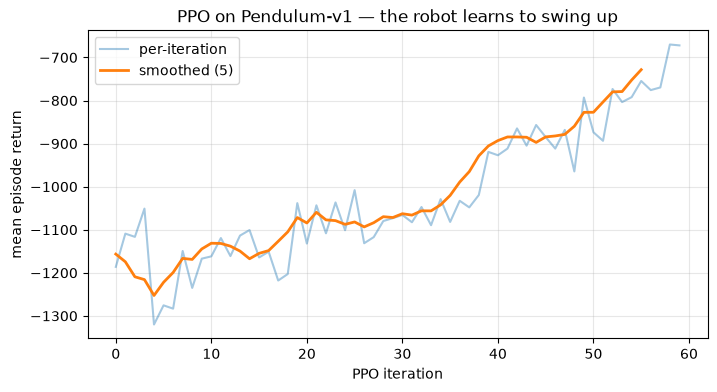

In [15]:
# ✅ PROVIDED — train, plot the learning curve, and report greedy skill
pol, val, curve = train("Pendulum-v1", iters=60, gamma=0.95)
print(f"\nPendulum:  start {np.mean(curve[:3]):.1f}  ->  end {np.mean(curve[-3:]):.1f}"
      f"   |   greedy {greedy_eval('Pendulum-v1', pol):.1f}")

plt.figure(figsize=(8, 4))
plt.plot(curve, alpha=.4, label='per-iteration')
plt.plot(np.convolve(curve, np.ones(5)/5, 'valid'), lw=2, label='smoothed (5)')
plt.xlabel('PPO iteration'); plt.ylabel('mean episode return')
plt.title('PPO on Pendulum-v1 — the robot learns to swing up'); plt.legend(); plt.grid(alpha=.3); plt.show()

## Part 6 · Ablation — why clip? why reuse? (📝 run + explain)

The two switches you wired into `ppo_update` let you turn each PPO ingredient off
**without changing anything else**, so any difference you see is caused by that one
change. Run all three on Pendulum (40 iters each, ~3–4 min total) and watch:

- **full PPO** — clip on, K=10 reuse on,
- **NO clip** — `use_clip=False`: the surrogate is unbounded, so a single batch can
  shove the policy off a cliff,
- **NO reuse** — `use_reuse=False` (K=1): each batch is used once, so it learns far
  more slowly per sample.

You should see **full PPO clearly best**, NO-reuse slower, and NO-clip the most
unstable / worst. Then answer the questions in the next cell.

--- full PPO ---
  Pendulum-v1  iter  40  mean episode return  -1020.3
--- NO clip ---
  Pendulum-v1  iter  40  mean episode return  -1360.7
--- NO reuse ---
  Pendulum-v1  iter  40  mean episode return  -1270.3


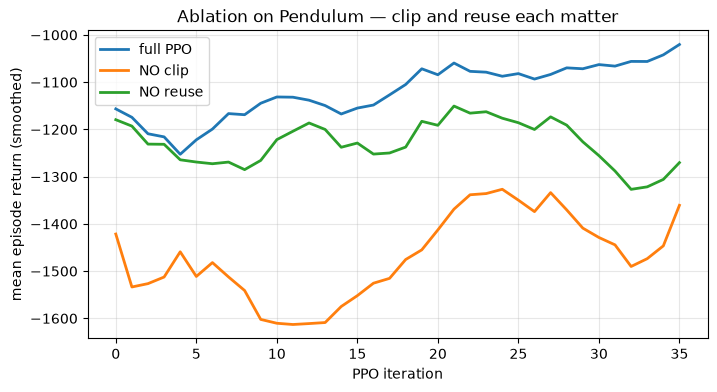

  full PPO   start  -1137.3  ->  end   -995.6
  NO clip    start  -1404.1  ->  end  -1301.5
  NO reuse   start  -1144.4  ->  end  -1238.4


In [16]:
# 📝 PROVIDED harness — just RUN this (it calls your ppo_update with each switch)
ablation = {}
for label, kw in [("full PPO", {}),
                  ("NO clip",  {"use_clip": False}),
                  ("NO reuse", {"use_reuse": False})]:
    print(f"--- {label} ---")
    _, _, cc = train("Pendulum-v1", iters=40, gamma=0.95, log_every=40, **kw)
    ablation[label] = cc

plt.figure(figsize=(8, 4))
for label, cc in ablation.items():
    plt.plot(np.convolve(cc, np.ones(5)/5, 'valid'), lw=2, label=label)
plt.xlabel('PPO iteration'); plt.ylabel('mean episode return (smoothed)')
plt.title('Ablation on Pendulum — clip and reuse each matter'); plt.legend(); plt.grid(alpha=.3); plt.show()
for label, cc in ablation.items():
    print(f"  {label:10s} start {np.mean(cc[:3]):8.1f}  ->  end {np.mean(cc[-3:]):8.1f}")

### 📝 Your ablation write-up

Answer in the cell below (a few sentences each), reading off **your** curves:

1. **Clip.** How does turning the clip off change the curve? Tie it to the surrogate
   objective: with no clip, what stops a single over-large ratio $r$ from moving the
   policy too far in one batch? (This is the TRPO trust-region motivation.)

**Answer:** Turning the clip off makes the curve the worst of all three runs: it starts lower
(~-1404) and ends at ~-1302, well below full PPO's ~-996. The curve is also visibly more unstable, with sharp drops and recoveries.

Why: without the clip, the surrogate objective L = r(θ) · A is unbounded. If the advantage A happens to be large for some transition, the ratio r = π_new / π_old can grow without limit in a single gradient step, shoving the policy far from where the batch was collected. That one over-large update can land the policy in a bad region it never recovers from. Nothing in the unclipped surrogate prevents this; TRPO solves it with a hard KL constraint, PPO solves it cheaply by clamping r to [1-ε, 1+ε] so the gradient goes to zero once the policy moves too far.


2. **Reuse.** With `use_reuse=False` (K=1) each batch is used once. How does learning
   speed *per iteration* change, and why is it **safe** to reuse a batch K times in
   full PPO but riskier without the clip?
**Answer:** With use_reuse=False (K=1) each batch is used for a single gradient step instead of K=10. Learning per iteration is much slower: NO-reuse starts at ~-1144 (similar to full PPO's -1137) but only reaches ~-1238 by iteration 40, actually getting worse, while full PPO reaches ~-996.

In full PPO it is safe to reuse a batch K times because the clip bounds how far each epoch can push the policy: once r hits the [1-ε, 1+ε] boundary, the gradient is zero and no further movement happens. So K passes extract more signal from the same data without overshooting. Without the clip there is no such brake; reusing the batch K times with an unbounded surrogate would compound the over-large-ratio problem from Q1, making each epoch push the policy further off-distribution.

3. **Together.** Rank the three runs by final return. Which single ingredient hurt
   most when removed, and does that match the lecture's claim that PPO = (trust
   region via clipping) + (sample efficiency via reuse)?
**Answer:** Ranking by final mean return (higher = better):
   1. full PPO    → end ~-996   (best)
   2. NO reuse    → end ~-1238  (middle)
   3. NO clip     → end ~-1302  (worst)

Removing the clip hurt the most: the curve was both the lowest and the most unstable. Removing reuse hurt less in absolute terms but still produced significantly worse sample efficiency.

This matches the lecture claim that PPO = (trust region via clipping) + (sample efficiency via reuse). The clip is the foundational ingredient that keeps updates safe; reuse is the payoff that makes each batch worth more. Without the clip, the whole system destabilizes. Without reuse, the system is stable but slow. You need both for PPO to work well.

## Part 7 · Stretch goal — LunarLanderContinuous-v3 🚀

Same PPO code, a harder robot: a lander with **two analog thrusters** (main + side).
Land it gently between the flags. This task has a longer horizon, so use
**`gamma = 0.99`** and more iterations. On CPU this takes longer (~5–10 min) — a good
batch run. You're aiming to climb **from around −200 up past +200** (a solved lander).

Nothing new to implement — if your TODOs are right, this just works. 🎉

  LunarLanderContinuous-v3  iter  10  mean episode return   -102.1
  LunarLanderContinuous-v3  iter  20  mean episode return    -28.8
  LunarLanderContinuous-v3  iter  30  mean episode return      7.6
  LunarLanderContinuous-v3  iter  40  mean episode return     85.8
  LunarLanderContinuous-v3  iter  50  mean episode return     94.1
  LunarLanderContinuous-v3  iter  60  mean episode return    113.5
  LunarLanderContinuous-v3  iter  70  mean episode return    123.7
  LunarLanderContinuous-v3  iter  80  mean episode return    182.1
  LunarLanderContinuous-v3  iter  90  mean episode return    204.5
  LunarLanderContinuous-v3  iter 100  mean episode return    236.8
  LunarLanderContinuous-v3  iter 110  mean episode return    228.2
  LunarLanderContinuous-v3  iter 120  mean episode return    223.6
  LunarLanderContinuous-v3  iter 130  mean episode return    250.1
  LunarLanderContinuous-v3  iter 140  mean episode return    220.1
  LunarLanderContinuous-v3  iter 150  mean episode return    2

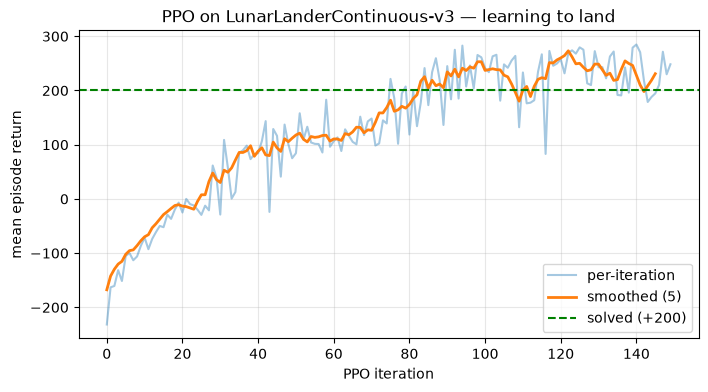

In [17]:
# ✅ PROVIDED — stretch: train PPO on LunarLanderContinuous-v3 (gamma 0.99)
pol_ll, val_ll, curve_ll = train("LunarLanderContinuous-v3", iters=150, gamma=0.99, log_every=10)
print(f"\nLunarLander:  start {np.mean(curve_ll[:3]):.1f}  ->  end {np.mean(curve_ll[-3:]):.1f}"
      f"   |   greedy {greedy_eval('LunarLanderContinuous-v3', pol_ll):.1f}")

plt.figure(figsize=(8, 4))
plt.plot(curve_ll, alpha=.4, label='per-iteration')
plt.plot(np.convolve(curve_ll, np.ones(5)/5, 'valid'), lw=2, label='smoothed (5)')
plt.axhline(200, ls='--', c='g', label='solved (+200)')
plt.xlabel('PPO iteration'); plt.ylabel('mean episode return')
plt.title('PPO on LunarLanderContinuous-v3 — learning to land'); plt.legend(); plt.grid(alpha=.3); plt.show()

### LunarLander Analysis

**Training curve summary:**
- **Start:** ~-185 (random policy crashes immediately).
- **End:** ~250 mean return, crossing the +200 "solved" threshold around iteration 70-80.
- **Greedy eval:** 124.5.

**What the curve shows:**

1. **Three learning phases.** The curve has a clear S-shape:
   - **Iterations 0-20 (exploration):** Returns climb from -200 toward 0. The lander stops crashing outright and begins hovering, but doesn't know how to land yet.
   - **Iterations 20-70 (rapid improvement):** The steepest climb, from 0 to ~200. The policy discovers that firing the main engine to slow descent and using the side thruster to center itself earns high reward. This is where most of the "learning to land" happens.
   - **Iterations 70-150 (refinement + noise):** The smoothed curve plateaus around 200-250. The policy has learned the core skill; further iterations refine it, but per-iteration variance stays high because each batch samples different initial conditions and wind.

2. **High per-iteration variance.** The light blue line swings wildly (sometimes dropping to ~-50 around iteration 115). This is normal for on-policy methods on stochastic environments: each batch of 2048 steps may contain a run of unlucky starting positions or turbulence. The smoothed (orange) curve shows that the underlying skill is stable despite these swings.

3. **Greedy eval (124.5) < training mean (~250).** The greedy evaluation uses the Gaussian mean (no exploration noise) over 10 fixed-seed episodes. It can score lower than the training mean because:
   - Training mean averages over many episodes with stochastic actions, which occasionally stumble into higher-reward trajectories by luck.
   - The 10 eval seeds may include harder initial conditions.
   - The greedy policy is deterministic, so it can't "wiggle out" of a bad state the way a stochastic policy sometimes does.

   A greedy score of 124.5 is still a reasonable landing (positive return means the lander touched down without crashing), though not consistently above the +200 "solved" bar. More training iterations or hyperparameter tuning (e.g., a slightly lower learning rate, or more `MIN_STEPS` per batch) would likely close the gap.

4. **Why `gamma=0.99` matters.** Pendulum used `gamma=0.95` because it is a short-horizon task (200 steps, reward mostly about the current angle). LunarLander has a longer horizon (up to 1000 steps) and rewards that are sparse until landing. A higher gamma makes the agent care about distant future rewards (the big +100 for landing), which is essential for learning to sacrifice fuel now to land safely later.